# Causal Discovery Benchmark Demo

This notebook provides a minimal end-to-end causal discovery example using built-in datasets in sktime.datasets.

We show:
- a benchmark causal dataset (sachs) with benchmark DAG edges
- a real macroeconomic mini-example
- simple adjacency heatmaps for quick visual inspection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sktime.datasets import load_sachs
from sktime.causal_discovery import NOTEARS

In [2]:
X, true_edges = load_sachs(return_true_graph=True)

print(f"Sachs benchmark shape: {X.shape}")
print(f"Number of benchmark edges: {len(true_edges)}")
X.head()

Sachs benchmark shape: (10000, 11)
Number of benchmark edges: 17


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11
0,3,1,3,3,3,3,1,1,1,3,3
1,3,1,3,3,3,3,3,1,1,2,3
2,3,1,3,3,3,3,3,1,1,3,3
3,3,1,3,3,1,3,2,2,3,3,3
4,3,1,2,1,3,3,1,1,2,3,1


In [3]:
def edge_list_to_adj(edges, nodes):
    idx = {n: i for i, n in enumerate(nodes)}
    adj = np.zeros((len(nodes), len(nodes)), dtype=int)
    for s, t in edges:
        if s in idx and t in idx:
            adj[idx[s], idx[t]] = 1
    return adj

def plot_adj(adj, title):
    plt.figure(figsize=(5, 4))
    plt.imshow(adj, cmap="Blues", vmin=0, vmax=1)
    plt.title(title)
    plt.xlabel("target")
    plt.ylabel("source")
    plt.colorbar(shrink=0.8)
    plt.tight_layout()
    plt.show()

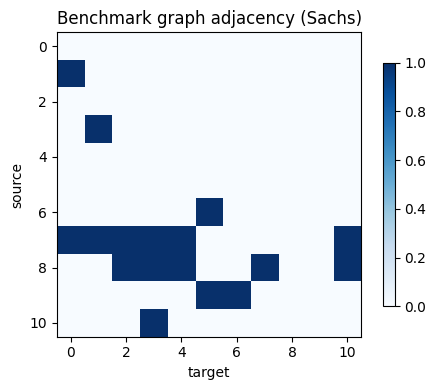

In [4]:
nodes = list(X.columns)
adj_true = edge_list_to_adj(true_edges, nodes)
plot_adj(adj_true, "Benchmark graph adjacency (Sachs)")

NOTEARS edges: 15


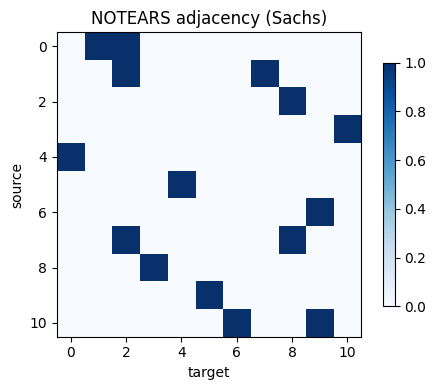

In [5]:
# NOTEARS baseline
notears = NOTEARS(lambda1=0.05, max_iter=20, h_tol=1e-6, w_threshold=0.2)
notears.fit(X)
adj_notears = notears.get_adjacency_matrix()
print("NOTEARS edges:", int(adj_notears.sum()))
plot_adj(adj_notears, "NOTEARS adjacency (Sachs)")

PC edges (abs adjacency): 22


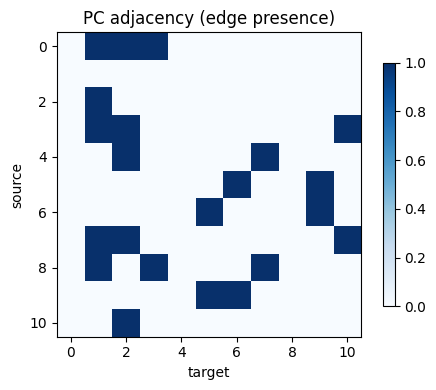

GES edges (abs adjacency): 20


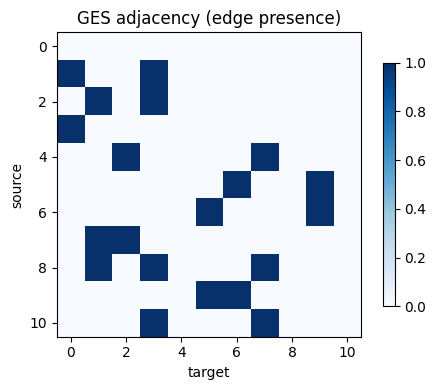

In [6]:
# Optional: run PC and GES if causal-learn is installed
try:
    from sktime.causal_discovery import PC, GES

    pc = PC(alpha=0.1)
    pc.fit(X)
    adj_pc = np.abs(pc.get_adjacency_matrix())
    print("PC edges (abs adjacency):", int((adj_pc > 0).sum()))
    plot_adj((adj_pc > 0).astype(int), "PC adjacency (edge presence)")

    ges = GES(score_func="local_score_BIC")
    ges.fit(X)
    adj_ges = np.abs(ges.get_adjacency_matrix())
    print("GES edges (abs adjacency):", int((adj_ges > 0).sum()))
    plot_adj((adj_ges > 0).astype(int), "GES adjacency (edge presence)")
except Exception as e:
    print("PC/GES optional demo skipped:", e)

## Real-data mini example (US macroeconomic subset)

This second example uses real economic variables and runs NOTEARS on a standardized subset.

Real macro example shape: (203, 5)
NOTEARS edges on macro subset: 4


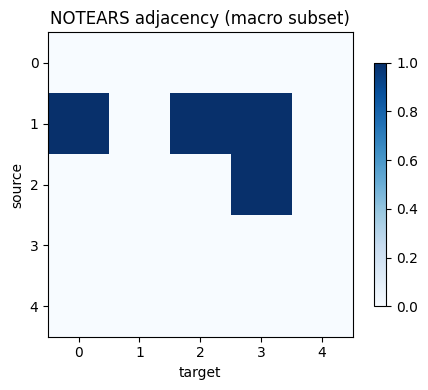

In [7]:
from sktime.datasets import load_macroeconomic

macro = load_macroeconomic()
cols = ["realgdp", "realcons", "realinv", "unemp", "infl"]
X_real = macro[cols].dropna().copy()
X_real = (X_real - X_real.mean()) / X_real.std(ddof=0)

notears_real = NOTEARS(lambda1=0.05, max_iter=20, h_tol=1e-6, w_threshold=0.15)
notears_real.fit(X_real)
adj_real = notears_real.get_adjacency_matrix()
print("Real macro example shape:", X_real.shape)
print("NOTEARS edges on macro subset:", int(adj_real.sum()))
plot_adj(adj_real, "NOTEARS adjacency (macro subset)")

## Notes

- This notebook is intentionally simple for lecture usage.
- You can switch benchmark datasets via `load_alarm()` or `load_asia()`.
- For quick sanity checks, compare predicted adjacency against benchmark edges.